# **Import Packages**

In [ ]:
# pip install pandas
# pip install numpy
# pip install datetime
# pip install matplotlib
# pip install seaborn
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mengintegrasikan dengan Folder Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

# **Import Dataset from CSV to Data Frame**

In [ ]:
#Import Dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset Projek/Salinan Online Retail Data.csv", header = 0)
df

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN
...,...,...,...,...,...,...,...
461768,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,NaN
461769,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,NaN
461770,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,NaN
461771,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,NaN


In [ ]:
# Informasi jenis data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


# **Data Cleaning**

In [ ]:
#Membuat salinan dataset
df_clean = df.copy()

# Mengubah tipe data kolom order date ke dalam datetime
df_clean['order_date'] = df_clean['order_date'].astype('datetime64[ns]')

# Membuat kolom baru bernama 'Year_Month'
df_clean['Year_Month'] = df_clean['order_date'].dt.to_period('M')

### Missing Value

In [ ]:
# Cek missing value
df_clean.isna().sum().sort_values(ascending=False)

,0
customer_id,100920
product_name,2718
product_code,0
order_id,0
quantity,0
order_date,0
price,0
Year_Month,0


In [ ]:
# Handling missing value dengan menghapusnya
df_clean = df_clean[~df_clean['customer_id'].isna()]
df_clean = df_clean[~df_clean['product_name'].isna()]

In [ ]:
# Cek ulang untuk memastikan tidak ada missing value lagi
df_clean.isna().sum()

,0
order_id,0
product_code,0
product_name,0
quantity,0
order_date,0
price,0
customer_id,0
Year_Month,0


### Handling Incorrect Format

In [ ]:
# Mengubah data di kolom 'product_name' menjadi huruf kecil semua dengan huruf kapial setiap awal kata
df_clean['product_name'] = df_clean['product_name'].str.title()
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month
0,493410,TEST001,This Is A Test Product.,5,2010-01-04 09:24:00,4.50,12346.0,2010-01
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01
2,493412,TEST001,This Is A Test Product.,5,2010-01-04 09:53:00,4.50,12346.0,2010-01
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01
...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12


In [ ]:
# Menghapus 'product_code' & 'product_name' yang mengandung kata 'Test'
df_clean = df_clean[(~df_clean['product_name'].str.contains('Test')) |
                    (~df_clean['product_code'].str.title().str.contains('Test'))]
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01
...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12


In [ ]:
# Membuat kolom baru 'status' berisi cancelled jika 'order_id' berawalan huruf c, dan delivered jika tidak berawalan huruf c
df_clean['status'] = np.where(df_clean['order_id'].str[:1] == 'C', 'cancelled', 'delivered')
df_clean

/tmp/ipykernel_1569/1517225198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['status'] = np.where(df_clean['order_id'].str[:1] == 'C', 'cancelled', 'delivered')


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,-1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Mengubah angka negatif pada kolom 'quantity' menjadi positif, karena anda negatif hanya menunjukkan status cancelled
df_clean['quantity'] = df_clean['quantity'].abs()
df_clean

/tmp/ipykernel_1569/1823639113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['quantity'] = df_clean['quantity'].abs()


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Menghapus baris dengan nilai 'price' negatif
df_clean = df_clean[df_clean['price']>0]
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered
...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered


In [ ]:
# Membuat kolom 'amount' yaitu perkalian 'quantity' dengan 'price'
df_clean ['amount'] = df_clean['quantity']*df_clean['price']
df_clean

/tmp/ipykernel_1569/2199709954.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean ['amount'] = df_clean['quantity']*df_clean['price']


,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount
1,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25
6,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80
7,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00
8,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10
9,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
461740,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25
461741,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
461742,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
461743,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90


### Mengganti product_name dari product_code yang memiliki beberapa product_name dengan salah satu product_name-nya yang paling sering muncul

In [ ]:
# Menghitung Jumlah Order berdasarkan 'product_code' & 'product_name' yang unik
most_freq_product_name = df_clean.groupby(['product_code', 'product_name'], as_index=False).agg(order_cnt = ('order_id', 'nunique')).sort_values(['product_code','order_cnt'], ascending=[True, False])
most_freq_product_name

,product_code,product_name,order_cnt
0,10002,Inflatable Political Globe,204
1,10080,Groovy Cactus Inflatable,3
2,10120,Doggy Rubber,31
3,10123C,Hearts Wrapping Tape,32
4,10123G,Army Camo Wrapping Tape,11
...,...,...,...
4304,D,Discount,78
4305,M,Manual,482
4306,PADS,Pads To Match All Cushions,14
4307,POST,Postage,57


In [ ]:
# memberikan ranking berdasarkan order_cnt untuk setiap product_code
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name

,product_code,product_name,order_cnt,rank
0,10002,Inflatable Political Globe,204,1.0
1,10080,Groovy Cactus Inflatable,3,1.0
2,10120,Doggy Rubber,31,1.0
3,10123C,Hearts Wrapping Tape,32,1.0
4,10123G,Army Camo Wrapping Tape,11,1.0
...,...,...,...,...
4304,D,Discount,78,1.0
4305,M,Manual,482,1.0
4306,PADS,Pads To Match All Cushions,14,1.0
4307,POST,Postage,57,1.0


In [ ]:
# Mengambil hanya rank = 1 dan menghapus kolom 'order_cnt' & 'rank' karena sudah tidak diperlukan
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])
most_freq_product_name

,product_code,product_name
0,10002,Inflatable Political Globe
1,10080,Groovy Cactus Inflatable
2,10120,Doggy Rubber
3,10123C,Hearts Wrapping Tape
4,10123G,Army Camo Wrapping Tape
...,...,...
4304,D,Discount
4305,M,Manual
4306,PADS,Pads To Match All Cushions
4307,POST,Postage


In [ ]:
# Menggabungkan 'most_freq_product_name' ke df_clean
df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}),
                          how='left', on='product_code')
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount,most_freq_product_name
0,C493411,21539,Retro Spots Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25,Red Retrospot Butter Dish
1,493414,21844,Retro Spot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80,Red Retrospot Mug
2,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00,Retro Spot Large Milk Jug
3,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10,New England Ceramic Cake Server
4,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50,Hand Open Shape Gold
...,...,...,...,...,...,...,...,...,...,...,...
360823,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25,Set Of 3 Butterfly Cookie Cutters
360824,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69,Hot Baths Soap Holder
360825,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69,Fairy Soap Soap Holder
360826,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90,Cream Sweetheart Egg Holder


In [ ]:
# Hapus kolom 'most_freq_product_name' supaya tidak ada dua kolom dengan isi yang sama
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,Year_Month,status,amount
0,C493411,21539,Red Retrospot Butter Dish,1,2010-01-04 09:43:00,4.25,14590.0,2010-01,cancelled,4.25
1,493414,21844,Red Retrospot Mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,91.80
2,493414,21533,Retro Spot Large Milk Jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,51.00
3,493414,37508,New England Ceramic Cake Server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,delivered,5.10
4,493414,35001G,Hand Open Shape Gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,delivered,8.50
...,...,...,...,...,...,...,...,...,...,...
360823,539988,84380,Set Of 3 Butterfly Cookie Cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12,delivered,1.25
360824,539988,84849D,Hot Baths Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
360825,539988,84849B,Fairy Soap Soap Holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12,delivered,1.69
360826,539988,22854,Cream Sweetheart Egg Holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12,delivered,9.90


In [ ]:
# Mengubah format kolom 'customer_id' sebagai tipe data string
df_clean['customer_id'] = df_clean['customer_id'].astype(str)

### Handling Outliers

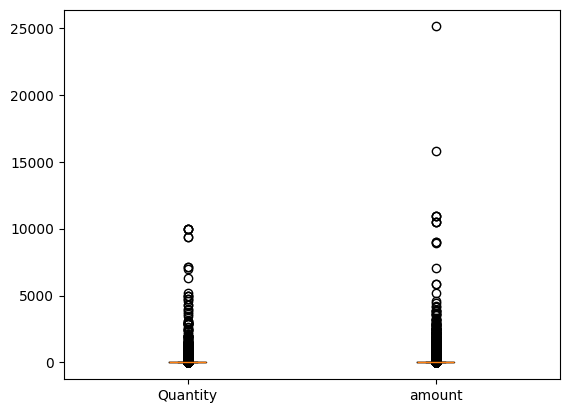

In [ ]:
# Cek outliers melalui boxplot
plt.boxplot([
    df_clean['quantity'],
    df_clean['amount']])

plt.xticks([1, 2], ['Quantity', 'amount'])
plt.show()

In [ ]:
# Dropping Outliers based on zscore
from scipy import stats
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']]))<3).all(axis=1)]
df_clean = df_clean.reset_index(drop=True)

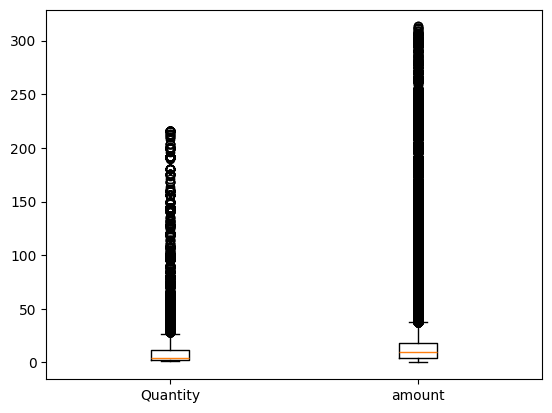

In [ ]:
# Periksa kembali outliers
plt.boxplot([
    df_clean['quantity'],
    df_clean['amount']])

plt.xticks([1, 2], ['Quantity', 'amount'])
plt.show()

In [ ]:
# Cek tipe data setelah diperbaiki
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358469 entries, 0 to 358468
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      358469 non-null  object        
 1   product_code  358469 non-null  object        
 2   product_name  358469 non-null  object        
 3   quantity      358469 non-null  int64         
 4   order_date    358469 non-null  datetime64[ns]
 5   price         358469 non-null  float64       
 6   customer_id   358469 non-null  object        
 7   Year_Month    358469 non-null  period[M]     
 8   status        358469 non-null  object        
 9   amount        358469 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5), period[M](1)
memory usage: 27.3+ MB


# **Measures User Retention Cohort**

In [ ]:
# Melakukan agregasi untuk menghitung 'order_id' yang unik berdasarkan pelanggan ('customer_id') yang bertransaksi setiap bulan ('Year_Month')
df_user_monthly = df_clean.groupby(['customer_id','Year_Month'], as_index=False).agg(order_cnt=('order_id','nunique'))
df_user_monthly

,customer_id,Year_Month,order_cnt
0,12346.0,2010-01,1
1,12346.0,2010-03,1
2,12346.0,2010-06,2
3,12346.0,2010-10,1
4,12608.0,2010-10,1
...,...,...,...
12039,18286.0,2010-06,1
12040,18286.0,2010-08,1
12041,18287.0,2010-05,1
12042,18287.0,2010-09,2


In [ ]:
# Menentukan dan membuat kolom cohort (bulan pertama kali customer melakukan transaksi) untuk setiap customer
df_user_monthly['cohort'] = df_user_monthly.groupby('customer_id')['Year_Month'].transform('min')
df_user_monthly

,customer_id,Year_Month,order_cnt,cohort
0,12346.0,2010-01,1,2010-01
1,12346.0,2010-03,1,2010-01
2,12346.0,2010-06,2,2010-01
3,12346.0,2010-10,1,2010-01
4,12608.0,2010-10,1,2010-10
...,...,...,...,...
12039,18286.0,2010-06,1,2010-06
12040,18286.0,2010-08,1,2010-06
12041,18287.0,2010-05,1,2010-05
12042,18287.0,2010-09,2,2010-05


In [ ]:
# Menghitung jarak bulan transaksi dengan kolom cohort dan jumlahkan dengan 1 supaya jarak bulan 0 menjadi 1 yang berarti transaksi pertama
from operator import attrgetter
df_user_monthly['period_num'] = (df_user_monthly['Year_Month'] - df_user_monthly['cohort']).apply(attrgetter('n')) + 1
df_user_monthly

,customer_id,Year_Month,order_cnt,cohort,period_num
0,12346.0,2010-01,1,2010-01,1
1,12346.0,2010-03,1,2010-01,3
2,12346.0,2010-06,2,2010-01,6
3,12346.0,2010-10,1,2010-01,10
4,12608.0,2010-10,1,2010-10,1
...,...,...,...,...,...
12039,18286.0,2010-06,1,2010-06,1
12040,18286.0,2010-08,1,2010-06,3
12041,18287.0,2010-05,1,2010-05,1
12042,18287.0,2010-09,2,2010-05,5


In [ ]:
# Membuat tabel pivot dengan index = 'cohort', columns = 'period_num', dan values = 'custumer_id'
df_user_monthly_pivot = df_user_monthly.pivot_table(index='cohort', columns='period_num', values='customer_id', aggfunc='nunique')
df_user_monthly_pivot

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,713.0,280.0,334.0,313.0,305.0,304.0,293.0,268.0,285.0,319.0,335.0,249.0
2010-02,461.0,154.0,128.0,161.0,152.0,121.0,119.0,159.0,153.0,166.0,100.0,NaN
2010-03,528.0,146.0,158.0,145.0,140.0,123.0,149.0,186.0,193.0,96.0,NaN,NaN
2010-04,326.0,82.0,75.0,63.0,69.0,79.0,98.0,101.0,50.0,NaN,NaN,NaN
2010-05,274.0,55.0,50.0,52.0,52.0,72.0,67.0,43.0,NaN,NaN,NaN,NaN
2010-06,266.0,53.0,56.0,60.0,65.0,85.0,39.0,NaN,NaN,NaN,NaN,NaN
2010-07,179.0,38.0,37.0,52.0,53.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,160.0,35.0,50.0,48.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,227.0,64.0,60.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Mengambil kolom pertama (jumlah customer yang melakukan transaksi pertama kali)
cohort_size = df_user_monthly_pivot.iloc[:, 0]
cohort_size

,1
cohort,
2010-01,713.0
2010-02,461.0
2010-03,528.0
2010-04,326.0
2010-05,274.0
2010-06,266.0
2010-07,179.0
2010-08,160.0
2010-09,227.0


In [ ]:
# Membagi kolom pertama ('cohort_size') dengan semua nilai di pivot table untuk mendapatkan retention rate
df_retention_cohort = df_user_monthly_pivot.divide(cohort_size, axis=0)
df_retention_cohort

period_num,1,2,3,4,5,6,7,8,9,10,11,12
cohort,,,,,,,,,,,,
2010-01,1.0,0.392707,0.468443,0.438990,0.427770,0.426367,0.410940,0.375877,0.399719,0.447405,0.469846,0.349229
2010-02,1.0,0.334056,0.277657,0.349241,0.329718,0.262473,0.258134,0.344902,0.331887,0.360087,0.216920,NaN
2010-03,1.0,0.276515,0.299242,0.274621,0.265152,0.232955,0.282197,0.352273,0.365530,0.181818,NaN,NaN
2010-04,1.0,0.251534,0.230061,0.193252,0.211656,0.242331,0.300613,0.309816,0.153374,NaN,NaN,NaN
2010-05,1.0,0.200730,0.182482,0.189781,0.189781,0.262774,0.244526,0.156934,NaN,NaN,NaN,NaN
2010-06,1.0,0.199248,0.210526,0.225564,0.244361,0.319549,0.146617,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.212291,0.206704,0.290503,0.296089,0.167598,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.218750,0.312500,0.300000,0.168750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.281938,0.264317,0.136564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Create User Retention Cohort Heatmap**

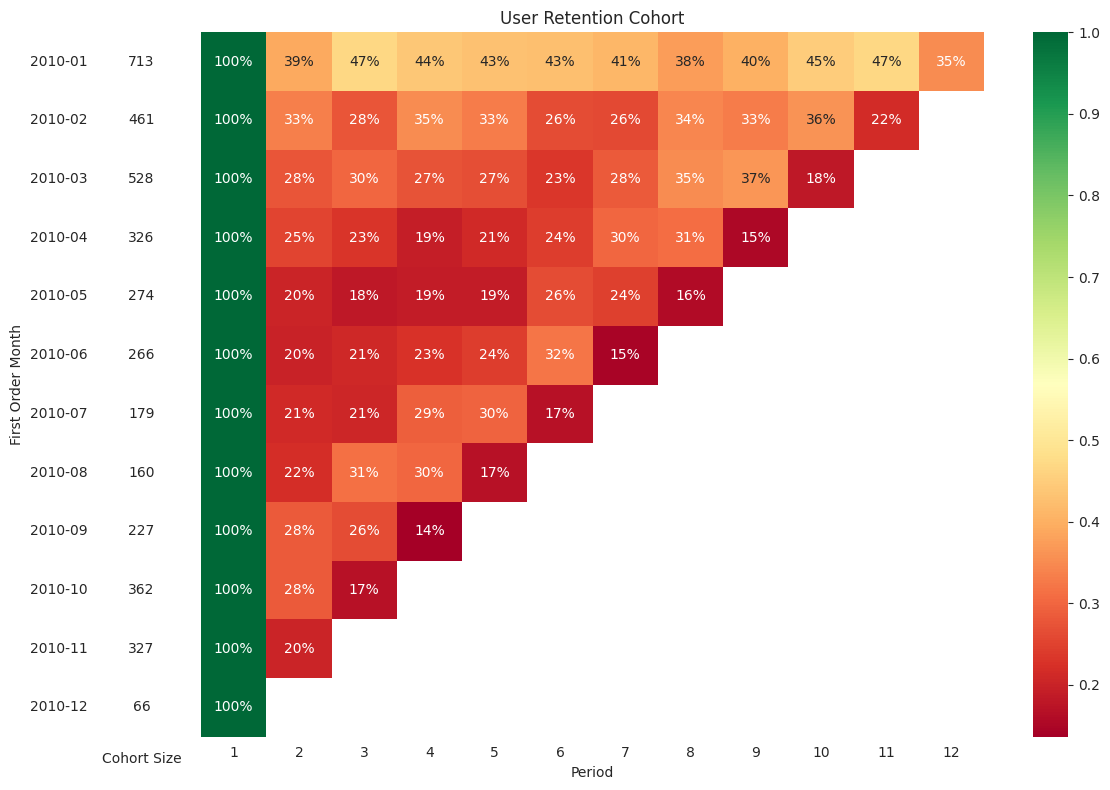

In [ ]:
import matplotlib.colors as mcolors
with sns.axes_style('white'):

    fig, ax = plt.subplots(1, 2, figsize=(12, 8), sharey=True, gridspec_kw={'width_ratios':[1, 11]})

    # user retention cohort
    sns.heatmap(df_retention_cohort, annot=True, fmt='.0%', cmap='RdYlGn', ax=ax[1])
    ax[1].set_title('User Retention Cohort')
    ax[1].set(xlabel='Period', ylabel='')

    # cohort size
    df_cohort_size = pd.DataFrame(cohort_size)
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(df_cohort_size, annot=True, cbar=False, fmt='g', cmap=white_cmap, ax=ax[0])
    ax[0].tick_params(bottom=False)
    ax[0].set(xlabel='Cohort Size', ylabel='First Order Month', xticklabels=[])

    fig.tight_layout()